# Блок 4. Задача 2: нейронная сеть прямого распространения, классификация

Цель: классифицировать рукописные цифры из датасета `Digits`.

Используется модель `MLPClassifier`.


In [6]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## Загрузка и анализ данных


In [7]:
digits = load_digits()
X = digits.data
y = digits.target

df_digits = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])
df_digits["target"] = y

display(df_digits.head())
print("Размер датасета:", df_digits.shape)
print("Распределение классов:")
print(df_digits["target"].value_counts().sort_index())


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


Размер датасета: (1797, 65)
Распределение классов:
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


## Подготовка данных


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


## Обучение модели


In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=1000, random_state=42, early_stopping=True)),
])

param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "mlp__alpha": [0.0001, 0.001],
    "mlp__learning_rate_init": [0.001, 0.01],
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
)
grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Лучшие параметры:", grid.best_params_)


Лучшие параметры: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.01}


## Метрики


Accuracy: 0.978
F1 macro: 0.978
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.94      0.93        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.92      1.00      0.96        36
           5       1.00      0.97      0.99        37
           6       1.00      0.97      0.99        36
           7       1.00      0.97      0.99        36
           8       0.97      0.94      0.96        35
           9       0.97      1.00      0.99        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



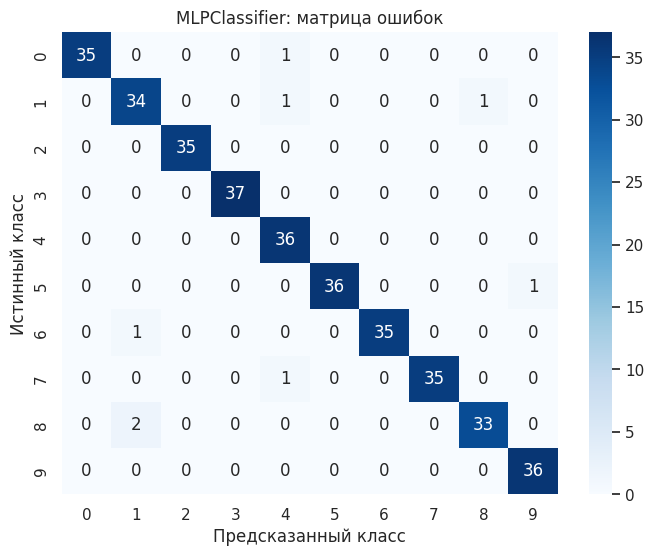

In [10]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("F1 macro:", round(f1_score(y_test, y_pred, average="macro"), 3))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("MLPClassifier: матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


## Вывод

Входные данные соответствуют задаче многоклассовой классификации: используется датасет `Digits` размером `1797 x 65`, в `X` входят `64` пиксельных признака, а целевая переменная `y = target` содержит `10` классов цифр от `0` до `9`. Распределение классов почти сбалансировано: от `174` до `183` объектов на класс.

По результатам `GridSearchCV` лучшими параметрами стали `hidden_layer_sizes = (64,)`, `alpha = 0.0001`, `learning_rate_init = 0.01`. По текущему запуску `MLPClassifier` получил `Accuracy = 0.978` и `F1 macro = 0.978` на тестовой выборке.

Качество классификации высокое, но не идеальное. По отчёту классификации слабее всего распознаётся класс `1` (`f1-score = 0.93`), также ниже среднего классы `4` и `8` (`f1-score = 0.96`). Классы `2` и `3` в текущем запуске распознаны без ошибок по precision/recall/f1. В целом нейронная сеть прямого распространения хорошо решает задачу классификации цифр по пиксельным признакам.
